In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import sys, importlib.util
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import neurite as ne

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

In [ ]:
import sys
from pathlib import Path
from torch.utils.data import Subset

for _candidate in [Path.cwd().resolve(), Path.cwd().resolve().parent, Path.cwd().resolve() / 'Voxelmorph']:
    if (_candidate / 'tuco_dataset.py').exists():
        if str(_candidate) not in sys.path:
            sys.path.insert(0, str(_candidate))
        break
else:
    raise FileNotFoundError('Could not find tuco_dataset.py from the current working directory')

from tuco_dataset import TucoDataset

torch.backends.cudnn.benchmark = True

DATA_ROOT = '../../Data/Tuco'
MAX_TRAIN = 20
MAX_VAL = 5
ORIENTATION = 'axial'

def _vols_to_slices(ds_split, max_n, orientation):
    ds = TucoDataset(DATA_ROOT, split=ds_split)
    if max_n is not None:
        ds = Subset(ds, range(min(max_n, len(ds))))
    mr_list, ct_list = [], []
    for sample in ds:
        mr = sample['moving'].squeeze(0).numpy()
        ct = sample['fixed'].squeeze(0).numpy()
        if orientation == 'coronal':
            mr = mr.transpose(1, 0, 2)
            ct = ct.transpose(1, 0, 2)
        elif orientation == 'sagittal':
            mr = mr.transpose(2, 0, 1)
            ct = ct.transpose(2, 0, 1)
        mr_list.append(mr.astype(np.float32))
        ct_list.append(ct.astype(np.float32))
    return np.concatenate(mr_list, axis=0), np.concatenate(ct_list, axis=0)

print('Loading train slices...')
x_train_mr, x_train_ct = _vols_to_slices('train', MAX_TRAIN, ORIENTATION)
print('Loading val slices...')
x_val_mr, x_val_ct = _vols_to_slices('val', MAX_VAL, ORIENTATION)
slice_shape = x_train_mr.shape[1:]
print(f'Train: {x_train_mr.shape[0]} slices  shape={slice_shape}')
print(f'Val: {x_val_mr.shape[0]}   slices')


In [ ]:
def vxm_data_generator(mr_slices, ct_slices, batch_size=8):
    n = mr_slices.shape[0]
    while True:
        idx = np.random.randint(0, n, size=batch_size)
        moving = torch.from_numpy(mr_slices[idx, np.newaxis]).to(device)
        fixed = torch.from_numpy(ct_slices[idx, np.newaxis]).to(device)
        yield moving, fixed

In [ ]:
class SpatialTransformer2D(nn.Module):
    def forward(self, src, flow):
        b, _, h, w = src.shape
        device = src.device
        yy, xx = torch.meshgrid(
            torch.arange(h, device=device),
            torch.arange(w, device=device), indexing='ij')
        base_grid = torch.stack((xx, yy), 0).float().unsqueeze(0).repeat(b, 1, 1, 1).to(flow)
        pts = base_grid + flow
        x = 2.0 * (pts[:, 0] / (w - 1)) - 1.0
        y = 2.0 * (pts[:, 1] / (h - 1)) - 1.0
        grid = torch.stack((x, y), dim=-1)
        return F.grid_sample(src, grid, mode='bilinear', padding_mode='border', align_corners=True)


def flow_grad_l2(flow):
    dx = flow[:, :, :, 1:] - flow[:, :, :, :-1]
    dy = flow[:, :, 1:, :] - flow[:, :, :-1, :]
    return F.pad(dx, (0, 1)).pow(2).mean() + F.pad(dy, (0, 0, 0, 1)).pow(2).mean()


def mind_loss_2d(x, y, d=2, patch_size=9):
    # 2D MIND (Modality-Independent Neighbourhood Descriptor) loss
    def _descriptor(img):
        p = patch_size // 2
        k = torch.ones(1, 1, patch_size, patch_size,
                       device=img.device, dtype=img.dtype) / (patch_size ** 2)
        mu = F.conv2d(img, k, padding=p)
        var = (F.conv2d(img ** 2, k, padding=p) - mu ** 2).clamp(min=0)
        noise = var.mean(dim=(1, 2, 3), keepdim=True).clamp(min=1e-5)

        shifts = [(0, d), (0, -d), (d, 0), (-d, 0), (d, d), (-d, -d)]
        desc = []
        for dy, dx in shifts:
            shifted = torch.roll(img, shifts=(dy, dx), dims=(2, 3))
            ssd = F.conv2d((img - shifted) ** 2, k, padding=p)
            desc.append(torch.exp(-ssd / (2.0 * noise)))
        return torch.cat(desc, dim=1)

    return F.mse_loss(_descriptor(x), _descriptor(y))

In [ ]:
class ConvBlock2D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.act = nn.LeakyReLU(0.2)

    def forward(self, x):
        return self.act(self.conv(x))


class VxmDense2D(nn.Module):
    def __init__(self, vol_shape, enc_feats=(16, 32, 32, 32), final_feats=(32, 16)):
        super().__init__()
        self.vol_shape = vol_shape

        self.encoders = nn.ModuleList()
        in_ch = 2
        for nf in enc_feats:
            self.encoders.append(ConvBlock2D(in_ch, nf))
            in_ch = nf
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock2D(enc_feats[-1], enc_feats[-1])

        self.decoders = nn.ModuleList()
        dec_in = enc_feats[-1]
        for skip_ch in reversed(enc_feats):
            self.decoders.append(ConvBlock2D(dec_in + skip_ch, skip_ch))
            dec_in = skip_ch

        self.final_conv0 = ConvBlock2D(dec_in, final_feats[0])
        self.final_conv1 = ConvBlock2D(final_feats[0], final_feats[1])
        self.flow = nn.Conv2d(final_feats[1], 2, kernel_size=3, padding=1)
        self.transformer = SpatialTransformer2D()

        self.apply(self._init_weights)
        nn.init.zeros_(self.flow.weight)
        nn.init.zeros_(self.flow.bias)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, src, tgt):
        x = torch.cat([src, tgt], dim=1)
        skips = []
        for enc in self.encoders:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        for skip, dec in zip(reversed(skips), self.decoders):
            x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=True)
            x = torch.cat([x, skip], dim=1)
            x = dec(x)

        x = self.final_conv0(x)
        x = self.final_conv1(x)
        flow = self.flow(x)
        moved = self.transformer(src, flow)
        return moved, flow

In [ ]:
model = VxmDense2D(vol_shape=slice_shape).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

_gen = vxm_data_generator(x_train_mr, x_train_ct, batch_size=1)
model.eval()
with torch.no_grad():
    _m, _f = next(_gen)
    _moved, _flow = model(_m, _f)
print('moved:', tuple(_moved.shape), '  flow:', tuple(_flow.shape))
del _m, _f, _moved, _flow, _gen
torch.cuda.empty_cache()

In [ ]:
batch_size = 8
steps_per_epoch = 200
val_steps = 50
epochs = 500
patience = 25
smooth_weight = 0.01

save_dir = '../trained_weights'
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, '2d_dense_best.pth')

train_history = []
val_history = []
best_loss = float('inf')
no_improve = 0

scaler = torch.amp.GradScaler('cuda')
train_gen = vxm_data_generator(x_train_mr, x_train_ct, batch_size=batch_size)
val_gen = vxm_data_generator(x_val_mr, x_val_ct, batch_size=batch_size)

for epoch in range(epochs):
    model.train()
    running_train = 0.0
    for _ in range(steps_per_epoch):
        moving, fixed = next(train_gen)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda'):
            moved, flow = model(moving, fixed)
            recon_loss = mind_loss_2d(fixed, moved)
            smooth_loss = flow_grad_l2(flow)
            loss = recon_loss + smooth_weight * smooth_loss
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_train += loss.item()

    epoch_train = running_train / steps_per_epoch
    train_history.append(epoch_train)

    model.eval()
    running_val = 0.0
    with torch.no_grad():
        for _ in range(val_steps):
            moving, fixed = next(val_gen)
            with torch.amp.autocast('cuda'):
                moved_v, flow_v = model(moving, fixed)
                loss_v = mind_loss_2d(fixed, moved_v) + smooth_weight * flow_grad_l2(flow_v)
            running_val += loss_v.item()

    epoch_val = running_val / val_steps
    val_history.append(epoch_val)
    print(f'Epoch {epoch+1}/{epochs} -- train: {epoch_train:.6f} | val: {epoch_val:.6f}')

    if epoch_val < best_loss:
        best_loss = epoch_val
        no_improve = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

train_history = np.array(train_history, dtype=np.float32)
val_history = np.array(val_history, dtype=np.float32)

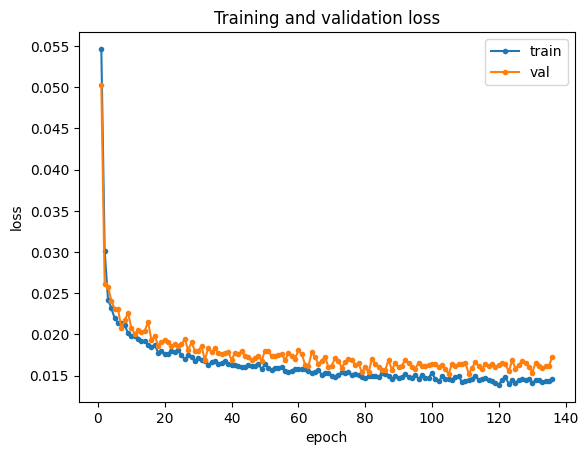

In [8]:
epochs_ran = np.arange(1, len(train_history) + 1)
plt.figure()
plt.plot(epochs_ran, train_history, '.-', label='train')
plt.plot(epochs_ran, val_history,   '.-', label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [ ]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()


def visualise_registration(split_name, mr_slices, ct_slices):
    _gen = vxm_data_generator(mr_slices, ct_slices, batch_size=1)
    moving, fixed = next(_gen)
    with torch.no_grad():
        moved, flow = model(moving, fixed)

    moving_np = moving[0, 0].cpu().numpy()
    fixed_np = fixed[0, 0].cpu().numpy()
    moved_np = moved[0, 0].cpu().numpy()
    flow_np = flow[0].permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(9, 3))
    for i, (img, title) in enumerate([
            (moving_np, 'moving (MR)'),
            (fixed_np, 'fixed (CT)'),
            (moved_np, 'moved')]):
        plt.subplot(1, 3, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f'{split_name} {title}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

    step = 4
    ne.plot.flow([flow_np[::step, ::step, :]], width=5)


visualise_registration('val', x_val_mr, x_val_ct)
visualise_registration('train', x_train_mr, x_train_ct)

In [10]:
final_path = os.path.join(save_dir, '2d_dense.pth')
torch.save(model.state_dict(), final_path)
print('Saved final model to', final_path)
print('Best val loss model is at', best_model_path)

Saved final model to ../trained_weights/2d_dense.pth
Best val loss model is at ../trained_weights/2d_dense_best.pth
